# DEEP DIVE

## Outline:
- Data requirements survey
- Intro esp-data repo
- File handling and file I/O
- Some utilities
- Config management
- Datasets
    - Creating shards
    - Loading sharded / unsharded datasets
    - Running stream processing

## Data requirements survey

- **accuracy** (what's in the data is real and has few / no errors, e.g. wrong labels)
- completeness (no missing or null values in columns / features)
- **consistency** (same format across different systems. e.g. dates as YYYY-MM-DD
- currency (how fresh or up-to-date is the data)
- precision (level of detail in the data e.g. metadata with recording equipment brand and make)
- privacy (data should be protected according to privacy regulations)
- **reasonableness** (data should make logical sense, e.g. an animal's age cannot be < 0)
- **integrity** (data should maintain its accuracy and consistency throughout its entire lifecycle)
- timeliness (data should be available when needed, e.g. real time access)
- uniqueness (no duplicates!)
- **validity** (data should conform to rules e.g. audio datasets should have audio file paths)

"Need to keep track of when missing data occurs (e.g., data was not collected for a certain time period, or audio is corrupted); easy to query correspondences across datatypes; organizing many usages of underlying raw data (different subsets of data, different annotation layers, etc.)"

"Priority is diversity + scale, with maximum behavioral context, and best available accuracy"

## Responses on data quality requirements

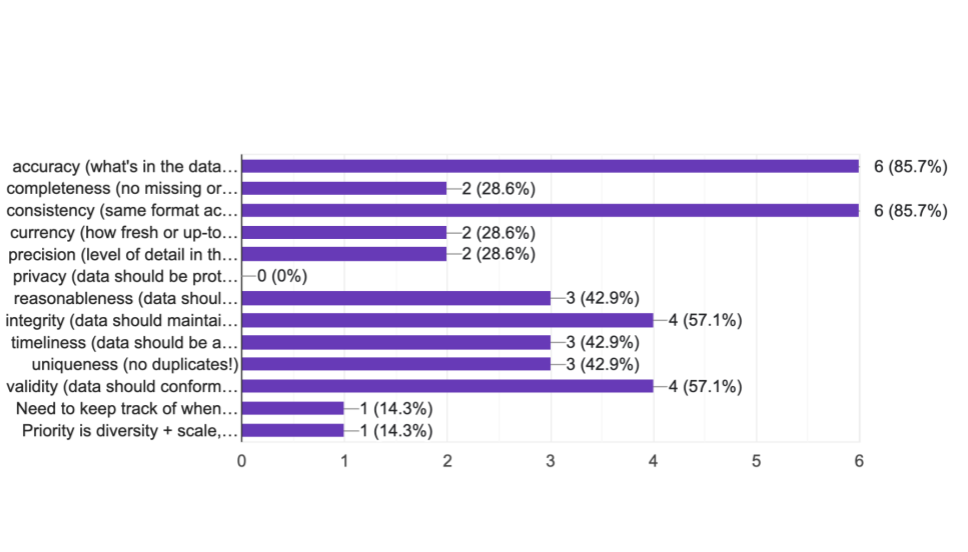

In [2]:
# from IPython.display import Image, display
# display(Image("/Users/gagan/esp_projects/EspDataDeepdive/assets/data_req1.png", width=1000, height=500))

### What are you main pain points ?
* Organizing dataset with many types of data, annotations and usages and with multiple people ..
* Buckets get confusing as project grows (names, versions)
* Copying lots of files around is slow..
* Lack of a standardized approach .. for merging diverse data types into a single master-dataset. 
* Sharing data with collaborators
* Finding data external and internal to us

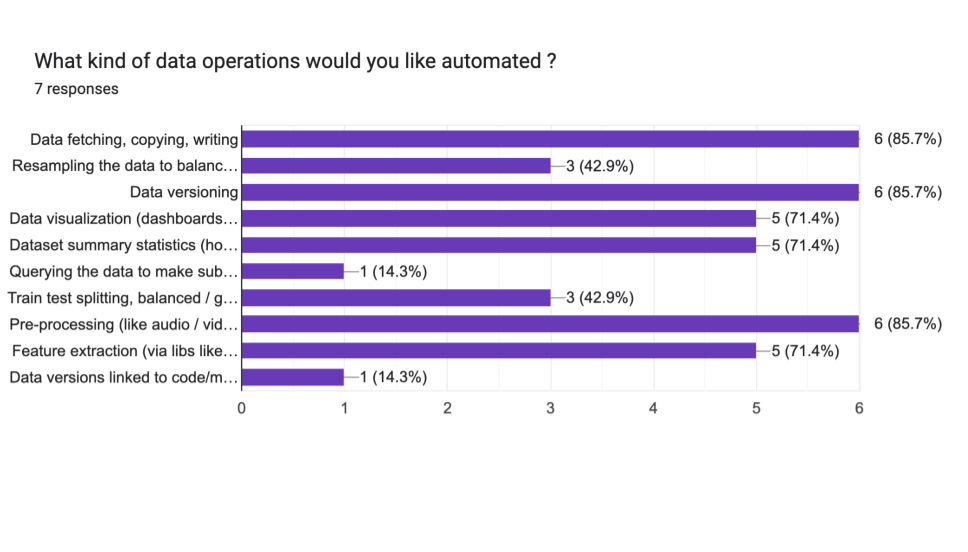

In [23]:
display(Image("/Users/gagan/esp_projects/EspDataDeepdive/assets/data_req2.png", width=1000, height=500))

## esp-data
PR: https://github.com/earthspecies/esp-data/tree/gn-first-modules

## Paths
### How to manage local and cloud paths ? 

In [4]:
from esp_data.io import AnyPath

p = AnyPath("../tests/fileio_test_folder/file1.txt")

print(p)
print(type(p))

../tests/fileio_test_folder/file1.txt
<class 'pathlib.PosixPath'>


In [5]:
# get extension
print(p.suffix)
# split path
print(p.parts)

.txt
('..', 'tests', 'fileio_test_folder', 'file1.txt')


In [7]:
p = AnyPath("gs://esp-ci-cd-tests/esp-data-tests/")
print(type(p))
print(p.exists())

<class 'cloudpathlib.gs.gspath.GSPath'>
True


#### We also have CloudFlare R2 buckets!

In [8]:
p = AnyPath("r2://esp-ci-cd-tests/esp-data-tests/")
print(type(p))
print(p.exists())
print(p.is_dir())
print(list(p.rglob("**/*local.txt")))

<class 'cloudpathlib.s3.s3path.S3Path'>
True
True
[S3Path('s3://esp-ci-cd-tests/esp-data-tests/temprandomfolder/random_local.txt'), S3Path('s3://esp-ci-cd-tests/esp-data-tests/temprandomfolder/random_local.txt')]


#### delete a file
```p.unlink()```
#### rename a file (moves it to a new location)
```p.rename(target=)```
#### open a file for read or write, mode = "r" or "w" or "rb"
```p.open(mode="r")```
#### download 
```p.download_to("local_file.txt")```
#### upload a file to a cloud location
```p.upload_from("/path/to/myfile.txt")```

See more here:
https://cloudpathlib.drivendata.org/stable/api-reference/cloudpath/

### Joining paths

In [11]:
p = AnyPath("gs://esp-ci-cd-tests/esp-data-tests/") / "some_subfolder/nri-battlesounds.mp3" 
print(p)

gs://esp-ci-cd-tests/esp-data-tests/some_subfolder/nri-battlesounds.mp3


## Functional API for File I/O

In [13]:
import esp_data.io.functional as F

#### F has the following functions
* copy
* create_file
* delete_dir
* makedirs
* delete_file
* download
* exists
* gcloud_rsync
* list_files
* yield_files
* open_file
* read_bytes
* read_text
* upload
* write_bytes
* write_rows_to_csv
* write_text

In [14]:
F.makedirs?

Signature:
F.makedirs(
    dir_path: str | os.PathLike | esp_data.paths.AnyPath,
    use_fs: bool = False,
    exist_ok: bool = True,
) -> bool
Docstring:
Create a directory at the given path.

CAUTION: Most cloud storage services do not allow creation of empty directories
(because they are not real filesystems).
So, this function will create a temporary file called ".temp" with 0 bytes
in the directory to check if it can be created.

Args:
    dir_path (str | os.PathLike | AnyPath): The path to the directory.
    use_fs (bool, optional): If True, use the FileSystem approach. Defaults to False.
    exist_ok (bool, optional): If True, do not raise an exception if the directory already exists. Defaults to True.

Returns:
    bool: True if the directory was created successfully
File:      ~/esp_projects/esp-data/esp_data/file_io/functional.py
Type:      function

#### Check for file exists

In [15]:
p = AnyPath("gs://esp-ci-cd-tests/esp-data-tests/") / "some_subfolder/nri-battlesounds.mp3"
print(p)
print(F.exists(p))

gs://esp-ci-cd-tests/esp-data-tests/some_subfolder/nri-battlesounds.mp3
True


#### Download a file 

In [10]:
F.download(p, destination="/Users/gagan/Desktop/")
F.exists("/Users/gagan/Desktop/nri-battlesounds.mp3")

True

#### Iterate over file names in a bucket

In [3]:
%%time
for file in F.yield_files("gs://esp-ci-cd-tests/esp-data-tests", pattern="**/*txt", use_fs=True):
    print(file)

gs://esp-ci-cd-tests/esp-data-tests/find_files_tests/file_find_cloud.txt
gs://esp-ci-cd-tests/esp-data-tests/non_empty/temp_file.txt
gs://esp-ci-cd-tests/esp-data-tests/random2.txt
gs://esp-ci-cd-tests/esp-data-tests/some_subfolder/random.txt
gs://esp-ci-cd-tests/esp-data-tests/some_subfolder/temp_file.txt
gs://esp-ci-cd-tests/esp-data-tests/subfolder/file1.txt
gs://esp-ci-cd-tests/esp-data-tests/subfolder/file2.txt
gs://esp-ci-cd-tests/esp-data-tests/subfolder/random1.txt
gs://esp-ci-cd-tests/esp-data-tests/subfolder/random2.txt
gs://esp-ci-cd-tests/esp-data-tests/subfolder/sub_folder/file3.txt
CPU times: user 32.3 ms, sys: 32.1 ms, total: 64.4 ms
Wall time: 2.85 s


#### Open a remote file for read

In [16]:
# find byte -> numpy parsers here!
from esp_data.io.parsers import read_audio_bytes

In [17]:
p = AnyPath("gs://esp-ci-cd-tests/esp-data-tests/") / "some_subfolder/nri-battlesounds.mp3"

with F.open_file(str(p), mode="rb") as f:
    audio_data, sr = read_audio_bytes(f.read(), extension="mp3")
    print(type(audio_data))
    print(f"Sample rate = {sr}")

<class 'numpy.ndarray'>
Sample rate = 44100


####  Open a remote file for write

In [24]:
import json

cfg = {"some-int": 2, "foo": "bar"}
p = AnyPath("gs://esp-ci-cd-tests/esp-data-tests/") / "some_subfolder/test_cfg.json"

with F.open_file(str(p), mode="w") as f:
    json.dump(cfg, f)

with F.open_file(str(p), mode="r") as f:
    cfg2 = json.load(f)

cfg == cfg2

True

#### GCP rsync

In [25]:
F.gcloud_rsync(
    source="gs://esp-ci-cd-tests/esp-data-tests/some_subfolder",
    destination="gs://esp-ci-cd-tests/esp-data-tests/newfolder",
    avoid_copy_if_same=True,
    gzip_in_flight="txt",
)

2025-03-05 14:11:44,849 - fileio_functional - INFO - Rsync completed successfully


In [26]:
%%time
F.list_files("gs://esp-ci-cd-tests/esp-data-tests/newfolder", pattern="*")

CPU times: user 32.1 ms, sys: 8.91 ms, total: 41 ms
Wall time: 2.48 s


['gs://esp-ci-cd-tests/esp-data-tests/newfolder/nri-battlesounds.mp3',
 'gs://esp-ci-cd-tests/esp-data-tests/newfolder/random.txt',
 'gs://esp-ci-cd-tests/esp-data-tests/newfolder/temp_file.txt',
 'gs://esp-ci-cd-tests/esp-data-tests/newfolder/test_cfg.json',
 'esp-ci-cd-tests/esp-data-tests/newfolder/nri-battlesounds.mp3',
 'esp-ci-cd-tests/esp-data-tests/newfolder/random.txt',
 'esp-ci-cd-tests/esp-data-tests/newfolder/temp_file.txt',
 'esp-ci-cd-tests/esp-data-tests/newfolder/test_cfg.json']

In [27]:
F.delete_dir("gs://esp-ci-cd-tests/esp-data-tests/newfolder")

True

In [28]:
F.exists("gs://esp-ci-cd-tests/esp-data-tests/newfolder")

False

## Configs and data validation

#### We use pydantic for data models 

Check here for a nice tutorial from Milad! https://www.notion.so/earthspecies/Pydantic-basics-in-5-mins-17becbb680d080aebfdace6b3f937185

In [19]:
from typing import Optional
from pydantic import Field, field_validator

from esp_data.config import DataSample, DatasetConfig

In [30]:
class ExampleSample(DataSample):
    """Defines the structure of a Beans0 sample.

    Fields inherited from DataSample:
        - source_dataset: str
        - license: str | None
        - metadata: dict | None
        - created_at: datetime (generated)
        - id: str (generated)
        - derived_from: str | None
        - version: str | None
    """

    # required
    file_name: str = Field(description="Audio filename, could be a url")

    @field_validator("file_name", mode="after")
    @classmethod
    def validate_file_name(cls, v: str) -> str:
        if AnyPath(v).suffix not in [".flac", ".mp3", ".wav"]:
            raise ValueError("Audio type not supported!")

    # we could have validators be other light weight models like AVES 

    
beans0_sample = ExampleSample(file_name="something.ogg", source_dataset="foo", license="bar", metadata={})

ValidationError: 1 validation error for ExampleSample
file_name
  Value error, Audio type not supported! [type=value_error, input_value='something.ogg', input_type=str]
    For further information visit https://errors.pydantic.dev/2.10/v/value_error

#### Dataset configs are also useful!

In [20]:
class Beans0DatasetConfig(DatasetConfig):
    """Defines the structure of a Beans0 dataset config.

    Fields inherited from DatasetConfig:
        - name: str
        - description: str
        - sources: list[str] | str
        - license: str
        - creator: str
        - version: str
        - created_at: str (generated datetime UTC)
        - changelog: str (optional)
    """

    metadata: Optional[dict] = Field(default_factory=lambda: {}, description="The metadata for the whole dataset")

In [21]:
cfg = {
    "name": "TEST",
    "creator": "Foo",
    "version": "0.0.0",
    "description": "Bar",
    "sources": "test",
    "license": "CC-BY-4.0",
}

beans0_cfg = Beans0DatasetConfig(**cfg)

In [22]:
beans0_cfg.update_changelog("Did something to the data")

In [23]:
beans0_cfg.generate_readme("README.md")

In [40]:
F.list_files("gs://esp-ml-datasets/beans0/processed/v0.1.0/", pattern="*md")

['gs://esp-ml-datasets/beans0/processed/v0.1.0/README.md']

In [24]:
print(F.read_text("gs://esp-ml-datasets/beans0/processed/v0.1.0/README.md"))

# Beans0
        ## Version

0.1.0


        ## Created At

2025-03-02 12:35:11.528403+00:00


        ## Creator

M.Hagiwara, masato at earthspecies dot org;
D. Robinson, david at earthspecies dot org;
M. Miron, marius at earthspecies dot org;
S. Keen, sara at earthspecies dot org;
G. Narula, gagan at earthspecies dot org;
M. Alizadeh, milad at earthspecies dot org;
O. Pietquin, olivier at earthspecies dot org


        ## License

The component datasets either have dataset level licenses or per file licenses.

    esc50: CC-BY-NC,
    rfcx: academic, research & non-commercial use,
    cbi: CC-BY-NC-SA,
    humbugdb": CC-BY,
    enabirds: CC0,
    hiceas: data are free to use without restriction,
    watkins: free for personal/academic uses,
    gibbons: CC-BY-NC-SA,
    lifestage: per file licenses, please see individual files,
    call-type: per file licenses, please see individual files,
    unseen-species-cmn: per file licenses, please see individual files,
    unseen-species-sci:

## Utilities

In [25]:
from esp_data.utils import make_id, make_simple_logger, run_as_async, utc_now_str

In [26]:
utc_now_str()

'2025-03-05T16:34:15.608684+00:00'

In [27]:
make_id()

'fe68f426-37f6-42ff-82ce-fb5f739ec0a1'

#### Make a simple console logger


In [28]:
logger = make_simple_logger("my_logger", add_file_handler=False)
logger.info("Yipee!")

2025-03-05 17:34:20,290 - my_logger - INFO - Yipee!


#### Run a background task

In [29]:
import asyncio


def copy_something_to_cloud_and_delete(source: str):
    F.upload(source=source, destination="gs://esp-ci-cd-tests/esp-data-tests/teststests/fileio_test_folder/file1.txt")
    F.delete_file("gs://esp-ci-cd-tests/esp-data-tests/teststests/fileio_test_folder/file1.txt")
    print("File exists ? ", F.exists("gs://esp-ci-cd-tests/esp-data-tests/teststests/fileio_test_folder/file1.txt"))


# creates non-blocking task
asyncio.create_task(run_as_async(copy_something_to_cloud_and_delete, source="../tests/fileio_test_folder/file1.txt"))

print("Print me first")

Print me first
File exists ?  False


## Datasets

#### Why create shards ? 

One of the issues we have is that most of our datasets are collections of a very large number of files.

This has some disadvantages:
- Too much time spent copying files
- Corrupt files may be mixed in with normal files
- Can't stream the dataset easily
- Hard to index into
- ....

Sharding is the idea that we should aggregate data into fewer, but larger chunks in formats that allow for 
things like *memory mapping* or *streaming* and faster, copying around.

F.list_files("gs://esp-ml-datasets/beans0/processed/v0.1.0/")

```
 'gs://esp-ml-datasets/beans0/processed/v0.1.0/README.md',
 'gs://esp-ml-datasets/beans0/processed/v0.1.0/checkpoint.json',
 'gs://esp-ml-datasets/beans0/processed/v0.1.0/dataset_config.json',
 'gs://esp-ml-datasets/beans0/processed/v0.1.0/metadata.csv',
 'gs://esp-ml-datasets/beans0/processed/v0.1.0/shard_000000.arrow',
 'gs://esp-ml-datasets/beans0/processed/v0.1.0/shard_000001.arrow',
 'gs://esp-ml-datasets/beans0/processed/v0.1.0/shard_000002.arrow',
 'gs://esp-ml-datasets/beans0/processed/v0.1.0/shard_000003.arrow',
 'gs://esp-ml-datasets/beans0/processed/v0.1.0/shard_000004.arrow',
 'gs://esp-ml-datasets/beans0/processed/v0.1.0/shard_000005.arrow', ....
```

### Creating sharded datasets

In [30]:
from esp_data.dataset.shard_creator import write_shard, create_sharded_dataset, SHARD_TYPES
SHARD_TYPES

['webdataset', 'arrow', 'parquet', 'hf']

In [31]:
import numpy as np
import pandas as pd

from esp_data.utils import make_id


def make_dummy_dataset(N: int):
    # dummy dataset
    cols = ["col1_str", "col2_int", "col3_jsonstr", "col4_float", "id"]
    data = {}
    data[cols[0]] = [f"str_{i}" for i in range(N)]
    data[cols[1]] = [i for i in range(N)]
    data[cols[2]] = [f'{{"key_{i}": "value_{i}"}}' for i in range(N)]
    data[cols[3]] = [i * 0.1 for i in range(N)]
    data[cols[4]] = [make_id() for _ in range(N)]

    return data


df = pd.DataFrame(make_dummy_dataset(N=1000))

In [32]:
import json

def sample_prep(data: dict):
    return {"data.json": json.dumps(data)}
    
metadata_df = create_sharded_dataset(data=df,
                                     output_path="gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/tar_dataset/tempfolder",
                                     num_samples_per_shard=500,
                                     sample_prep_function=sample_prep,
                                     num_workers=1,
                                     shard_type="webdataset",
                                     save_metadata_as="metadata.parquet", # also csv, tsv, or json ok
                                     dataset_config=None,
                                     merge_data_and_metadata=True)

2025-03-05 17:40:53,120 - shard_creator_module - WARNING - Metadata has changed since last checkpoint. Starting fresh.
2025-03-05 17:40:53,122 - shard_creator_module - INFO - Loaded checkpoint with 0 completed chunks.
/Users/gagan/esp_projects/esp-data/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
2025-03-05 17:40:53,132 - shard_creator_module - INFO - 
=== Dataset Sharding Process ===
2025-03-05 17:40:53,133 - shard_creator_module - INFO - Total samples: 1000, Shards: 2, Samples per shard: 500



Processing shards:   0%|                                                      | 0/2 [00:00<?…

# writing gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/tar_dataset/tempfolder/shard_000000.tar 0 0.0 GB 0


Shard 00000:   0%|                                                | 0/500 [00:00<?, ?it/s]

# writing gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/tar_dataset/tempfolder/shard_000001.tar 0 0.0 GB 0


Shard 00001:   0%|                                                | 0/500 [00:00<?, ?it/s]

2025-03-05 17:41:00,222 - shard_creator_module - WARNING - No dataset config provided. Creating skeleton config..
2025-03-05 17:41:04,073 - shard_creator_module - INFO - 
=== Processing Summary ===
2025-03-05 17:41:04,074 - shard_creator_module - INFO - - Total files processed successfully: 1000
2025-03-05 17:41:04,075 - shard_creator_module - INFO - - Total files failed: 0
2025-03-05 17:41:04,076 - shard_creator_module - INFO - - Success rate: 100.00%
2025-03-05 17:41:04,076 - shard_creator_module - INFO - - Total time taken: 13.02 seconds


In [5]:
F.list_files("gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/tar_dataset/tempfolder")

['gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/tar_dataset/tempfolder/README.md',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/tar_dataset/tempfolder/checkpoint.json',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/tar_dataset/tempfolder/dataset_config.json',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/tar_dataset/tempfolder/metadata.parquet',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/tar_dataset/tempfolder/shard_000000.tar',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/tar_dataset/tempfolder/shard_000001.tar']

### There's also a slightly lower level api with more control

In [6]:
# Create batches of a dataframe
num_samples_per_shard = 100
num_samples = len(df)
num_shards = int(np.ceil(num_samples / num_samples_per_shard))

batched_df = [df.iloc[i : i + num_samples_per_shard] for i in range(0, len(df), num_samples_per_shard)]

print(f"Number of shards that will be created: {num_shards}")

Number of shards that will be created: 10


In [8]:
output_path = "gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder"

In [9]:
for i, batch in enumerate(batched_df):
    write_shard(df, shard_id=i, output_path=output_path, output_format="arrow", sample_prep_function=None)


Shard 00000:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00001:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00002:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00003:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00004:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00005:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00006:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00007:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00008:   0%|                                               | 0/1000 [00:00<?, ?it/s]

Shard 00009:   0%|                                               | 0/1000 [00:00<?, ?it/s]

In [4]:
F.list_files("gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder", "*arrow", use_fs=True)

['gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000000.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000001.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000002.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000003.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000004.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000005.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000006.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000007.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/shard_000008.arrow',
 'gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/s

### Loading datasets

In [34]:
from esp_data.dataset.datasets import load_dataset as lds
from esp_data.dataset.datasets import DATASET_TYPES

In [35]:
DATASET_TYPES

['pandas',
 'webdataset',
 'arrow',
 'csv',
 'tsv',
 'json',
 'parquet',
 'audiofolder',
 'imagefolder',
 'local_hf',
 'bucket_hf',
 'hf_hub']

Load a dataset with copy to local huggingface cache (".cache/huggingface/datasets")

In [36]:
ds = lds(
    dataset_type="bucket_hf",
    path="gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder",
    streaming=False,
    file_pattern="shard*arrow",
)

2025-03-05 17:44:37,221 - hf_dataset - WARNING - Config file not found at gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/arrow_dataset/tempfolder/dataset_config.json, creating an empty new one


In [37]:
ds

HFDataset: unknown, version: 0.0.0, num samples: 10000, columns: ['col1_str', 'col2_int', 'col3_jsonstr', 'col4_float', 'id']

In [38]:
len(ds)

10000

In [39]:
ds[0]

{'col1_str': 'str_0',
 'col2_int': 0,
 'col3_jsonstr': '{"key_0": "value_0"}',
 'col4_float': 0.0,
 'id': 'c829c9ae-a57d-400b-9224-c22b0c170df7'}

In [40]:
ds.save_to_path("./tempfolder")

Saving the dataset (0/1 shards):   0%|          | 0/10000 [00:00<?, ? examples/s]

In [41]:
dslocal = lds(dataset_type="local_hf", path="./tempfolder", streaming=False, split="train")

In [42]:
dslocal

HFDataset: unknown, version: 0.0.0, num samples: 10000, columns: ['col1_str', 'col2_int', 'col3_jsonstr', 'col4_float', 'id']

In [43]:
dslocal.config

DatasetConfig(name='unknown', creator='unknown', version='0.0.0', description='none', sources=['none'], created_at=datetime.datetime(2025, 3, 5, 16, 44, 37, 223532, tzinfo=datetime.timezone.utc), license='UNKNOWN', changelog='')

Let's load a dataset from huggingface hub

In [44]:
ds1 = lds(dataset_type="hf_hub", path="stanfordnlp/imdb", trust_remote_code=True, split="train")
ds1

HFDataset: imdb, version: 0.0.0, num samples: 25000, columns: ['text', 'label']

In [45]:
ds1.config

DatasetConfig(name='imdb', creator='see description', version='0.0.0', description="DatasetInfo(description='', citation='', homepage='', license='', features={'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['neg', 'pos'], id=None)}, post_processed=None, supervised_keys=None, builder_name='parquet', dataset_name='imdb', config_name='plain_text', version=0.0.0, splits={'train': SplitInfo(name='train', num_bytes=33435948, num_examples=25000, shard_lengths=None, dataset_name='imdb'), 'test': SplitInfo(name='test', num_bytes=32653810, num_examples=25000, shard_lengths=None, dataset_name='imdb'), 'unsupervised': SplitInfo(name='unsupervised', num_bytes=67113044, num_examples=50000, shard_lengths=None, dataset_name='imdb')}, download_checksums={'hf://datasets/stanfordnlp/imdb@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/plain_text/train-00000-of-00001.parquet': {'num_bytes': 20979968, 'checksum': None}, 'hf://datasets/stanfordnlp/imdb@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/p

Load a csv (or tsv, json, parquet..) dataset from a bucket with pandas

In [46]:
ds2 = lds(dataset_type="pandas", path="gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/csv_dataset/test.csv")

In [ ]:
# ds2 = lds(dataset_type="pandas", path="gs://esp-ci-cd-tests/esp-data-tests/benchmark_dataset/csv_dataset/test.csv")

In [47]:
ds2.shape

(1000, 5)

In [48]:
ds2.head(2)

,col1_str,col2_int,col3_jsonstr,col4_float,id
0,str_0,0,"{""key_0"": ""value_0""}",0.0,69ecb927-3e58-4545-b1d0-c6951fa957d3
1,str_1,1,"{""key_1"": ""value_1""}",0.1,69ecb927-3e58-4545-b1d0-c6951fa957d3


### Streaming data

In [1]:
from esp_data.dataset.datasets import load_dataset as lds

In [2]:
import json
from esp_data.io.parsers import read_audio_bytes


def data_processor(data: dict):
    audio, _ = read_audio_bytes(data["audio.wav"], "wav")
    metadata = json.loads(data["metadata.json"])
    return {"audio": audio, **metadata}

In [3]:
ds = lds(
    "webdataset",
    path="gs://esp-ml-datasets/beans0/processed/v0.1.1/",
    file_pattern="shard*tar",
    load_metadata=False,  # This will try and load a metadata.xx (csv, parquet or json) file, which contains an index
    data_processor=data_processor,
    shuffle_size=1000,  # will shuffle within shards in a buffer of 1000 samples
)

In [4]:
%%time
for sample in ds:
    break

Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe
<function Pipe.__del__ at 0x12306b010>
Traceback (most recent call last):
  File "/Users/gagan/esp_projects/esp-data/.venv/lib/python3.10/site-packages/webdataset/gopen.py", line 147, in __del__
    self.close()
  File "/Users/gagan/esp_projects/esp-data/.venv/lib/python3.10/site-packages/webdataset/gopen.py", line 135, in close
    self.wait_for_child()
  File "/Users/gagan/esp_projects/esp-data/.venv/lib/python3.10/site-packages/webdataset/gopen.py", line 85, in wait_for_child
    raise IOError(f"{self.args}: exit {self.status} (read) {info}")
OSError: (("gsutil cat 'gs://esp-ml-datasets/beans0/processed/v0.1.1/shard_000054.tar'",), {'shell': True, 'bufsize': 8192}): exit 120 (read) {}


CPU times: user 142 ms, sys: 110 ms, total: 252 ms
Wall time: 5.48 s


In [50]:
sample.keys()

dict_keys(['audio', 'source_dataset', 'metadata', 'id', 'created_at', 'license', 'file_name', 'instruction', 'instruction_text', 'output', 'task', 'dataset_name', '__key__'])

In [51]:
sample["metadata"]

'{"duration": 10.0, "sample_rate": 16000}'

In [52]:
sample["audio"].shape

(160000,)

In [53]:
from IPython.display import display, Audio
display(Audio(data=sample["audio"], rate=16000))

In [24]:
sample["license"]

'http://creativecommons.org/licenses/by-nc/4.0/'

In [25]:
sample["instruction_text"]

'Caption the audio, using the common name for any animal species.'

### Batched streaming with webdataset 🦾

Let's compute mel spectrograms in batches directly without using the apply_fn

In [30]:
import torch
import torchaudio.transforms as T
import torch.nn.functional as nnf


def torch_mel_spec(data: dict) -> torch.Tensor:
    """Create mel spectrograms on the fly"""
    data = data_processor(data)
    audio = torch.from_numpy(data["audio"]).to(torch.float32)

    sr = data.get("sample_rate", 16000)
    if sr != 16000:
        resampler = T.Resample(sr, new_freq=16000)
        audio = resampler(audio)

    # clip to max len 10 sec
    maxlen = 10 * 16000
    audio = audio[:maxlen]
    # or pad to 10 sec
    if len(audio) < maxlen:
        audio = nnf.pad(audio, (1, maxlen - len(audio) - 1), "constant", 0)

    transform = T.MelSpectrogram(sample_rate=16000, n_fft=256, n_mels=32)
    mel_specgram = transform(audio)
    return mel_specgram

In [35]:
ds = lds(
    "webdataset",
    path="gs://esp-ml-datasets/beans0/processed/v0.1.1/",
    file_pattern="shard*tar",
    load_metadata=False,
    data_processor=torch_mel_spec,
    shuffle_size=100,
    batch_size=100,
    batch_collate_fn=torch.stack,
)

In [ ]:
%%time # takes about 10 sec outside of GCP network
for batch in ds:
    break

In [37]:
batch.shape

torch.Size([100, 32, 1251])

## Serializable pipelines

In [1]:
from esp_data.dataset.transforms import TransformPipeline, create_pipeline

In [2]:
transforms = [
    {
        "module_path": "esp_data.test_module",
        "function_name": "normalize",
        "parameters": {"mean": 0, "std": 1}
    },
    {
        "module_path": "esp_data.test_module",
        "function_name": "add_noise",
        "parameters": {"noise_level": 0.1}
    }
]

pipeline = create_pipeline(
    transforms=transforms,
    name="normalize_and_augment",
    description="Normalizes data and adds noise",
    git_repo_path="~/esp_projects/esp-data/"
)

# Save pipeline configuration
print(pipeline.to_dict())

pipeline.save("pipeline_config.json")

# Load and use pipeline
loaded_pipeline = TransformPipeline.load("pipeline_config.json")

{'steps': [{'module_path': 'esp_data.test_module', 'function_name': 'normalize', 'parameters': {'mean': 0, 'std': 1}, 'version': '0.1.0', 'is_class_method': False, 'class_name': None, 'init_parameters': None}, {'module_path': 'esp_data.test_module', 'function_name': 'add_noise', 'parameters': {'noise_level': 0.1}, 'version': '0.1.0', 'is_class_method': False, 'class_name': None, 'init_parameters': None}], 'name': 'normalize_and_augment', 'git_commit': '1eb1899b786a4e685fbd4a9d7d13e2dae995f72d', 'git_repo_path': '~/esp_projects/esp-data/', 'created_at': '2025-03-05T15:49:51.363505', 'description': 'Normalizes data and adds noise'}


In [3]:
import numpy as np
data = {"x": np.ones(10)}
data = loaded_pipeline(data)
data

array([0.96985867, 0.94215705, 1.06241272, 1.09490283, 1.03606868,
       1.09076455, 1.15640412, 0.86250835, 1.0833933 , 1.04328673])

## esp-data

```
├── README.md
├── docs
├── esp_data
│   ├── __init__.py
│   ├── config
│   │   ├── __init__.py
│   │   ├── db_config.py
│   │   └── project_config.py
│   ├── dataset
│   │   ├── __init__.py
│   │   ├── base.py
│   │   ├── datasets.py
│   │   ├── hf.py
│   │   ├── shard_creator.py
│   │   ├── transforms.py
│   │   ├── utils.py
│   │   └── webds.py
│   ├── db
│   │   ├── __init__.py
│   │   ├── bq.py
│   │   ├── caches.py
│   │   └── utils.py
│   ├── file_io
│   │   ├── __init__.py
│   │   ├── functional.py
│   │   ├── parsers.py
│   │   └── utils.py
│   ├── paths.py
│   └── utils.py
├── notebooks
├── pyproject.toml
├── uv.lock
├── requirements.txt
├── scripts
├── tests
```

## NEXT STEPS

- Finish PR and merge first version v0.1.0 of esp-data
- Benchmarking webdataset / arrow, making improvements on latency etc.
- Refactoring, making the api simpler and more "auto-magic"
- Upcoming features:
    - Exporting metadata to BigQuery tables
    - Exporting datasets with versioning, changelogs
    - **DOCS**